# Astronomical Infrared Excess Analysis

This notebook loads SEIP infrared catalog data from the GitHub repository, cleans the data, engineers infrared flux-ratio features, identifies potential infrared-excess candidates, and uses clustering/PCA for exploration.

## 1. Clone the GitHub Repository

In [1]:
!git clone https://github.com/AxelRaphael29/seip-infrared-excess-analysis.git
%cd seip-infrared-excess-analysis

Cloning into 'seip-infrared-excess-analysis'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 12 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 7.82 MiB | 10.28 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/seip-infrared-excess-analysis


## 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

## 3. Load the SEIP Data


In [3]:
df = pd.read_csv("SEIP_data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (17464, 217)


,objid,crowded,badbkgmatch,ra,dec,l,b,nmatches,nreject,nbands,...,E(BP-RP),b_E(BP-RP)_x,B_E(BP-RP)_xa,Lib,RAJ2000,DEJ2000,e_RAJ2000,e_DEJ2000,RADEcorJ2000,angDist
0,SSTSL2 J152742.67+023551.8,0,0,231.927823,2.597747,6.474539,45.311356,1,0,7,...,NaN,NaN,NaN,NaN,231.927909,2.597755,0.291128,0.313270,-0.3389,0.585150
1,SSTSL2 J053049.72-670554.9,0,0,82.707184,-67.098598,277.220641,-32.640063,1,0,7,...,NaN,NaN,NaN,NaN,82.707144,-67.098660,0.287631,0.330409,-0.0930,0.567153
2,SSTSL2 J153607.88+384214.4,0,0,234.032847,38.704015,62.261412,53.892852,1,0,7,...,NaN,NaN,NaN,NaN,234.032752,38.703991,0.221318,0.262916,0.2171,0.536094
3,SSTSL2 J224656.98+602924.5,0,0,341.737456,60.490152,108.178973,1.234394,1,0,7,...,0.2299,0.2288,0.2310,MARCS,341.737342,60.490154,0.229804,0.195389,-0.2023,0.223976
4,SSTSL2 J022523.15-733726.6,0,0,36.346464,-73.624064,294.251396,-41.883553,1,0,7,...,0.1264,0.1251,0.1278,PHOENIX,36.347209,-73.623960,0.211948,0.207205,-0.0020,0.463367


## 4. Select Infrared Features

This project focuses on shorter infrared bands and a longer 24 micron band. If the 24 micron flux is unusually large compared to the shorter wavelengths, the object may show infrared excess.

In [4]:
features = [
    "i1_f_ap2",  # 3.6 micron
    "i2_f_ap2",  # 4.5 micron
    "i4_f_ap2",  # 8.0 micron
    "m1_f_psf"   # 24 micron
]

df_ir = df[features].copy()
df_ir.head()

,i1_f_ap2,i2_f_ap2,i4_f_ap2,m1_f_psf
0,491700.0,304300.0,117500.0,13860.0
1,24090.0,16890.0,6279.0,653.9
2,16810.0,11560.0,4244.0,581.9
3,20870.0,14280.0,5429.0,865.0
4,15220.0,10590.0,3795.0,628.8


## 5. Clean the Data

Rows with missing, infinite, or non-positive flux values are removed because ratios and logarithms require positive values.

In [5]:
# Replace infinite values with NaN
df_ir = df_ir.replace([np.inf, -np.inf], np.nan)

# Remove rows with missing values
df_ir = df_ir.dropna()

# Keep only rows where all selected fluxes are positive
df_ir = df_ir[(df_ir > 0).all(axis=1)].copy()

print("Final usable sample size:", len(df_ir))
df_ir.head()

Final usable sample size: 17387


,i1_f_ap2,i2_f_ap2,i4_f_ap2,m1_f_psf
0,491700.0,304300.0,117500.0,13860.0
1,24090.0,16890.0,6279.0,653.9
2,16810.0,11560.0,4244.0,581.9
3,20870.0,14280.0,5429.0,865.0
4,15220.0,10590.0,3795.0,628.8


## 6. Feature Engineering

Create flux-ratio features comparing 24 micron emission to shorter infrared wavelengths. Log transformations are used because astronomical flux values can span large ranges.

In [6]:
# Ratio-based excess features
df_ir["m1_i1_ratio"] = df_ir["m1_f_psf"] / df_ir["i1_f_ap2"]
df_ir["m1_i2_ratio"] = df_ir["m1_f_psf"] / df_ir["i2_f_ap2"]
df_ir["m1_i4_ratio"] = df_ir["m1_f_psf"] / df_ir["i4_f_ap2"]

# Log flux features
df_ir["log_i1"] = np.log10(df_ir["i1_f_ap2"])
df_ir["log_i2"] = np.log10(df_ir["i2_f_ap2"])
df_ir["log_i4"] = np.log10(df_ir["i4_f_ap2"])
df_ir["log_m1"] = np.log10(df_ir["m1_f_psf"])

# Log ratio features
df_ir["log_m1_i1"] = np.log10(df_ir["m1_i1_ratio"])
df_ir["log_m1_i2"] = np.log10(df_ir["m1_i2_ratio"])
df_ir["log_m1_i4"] = np.log10(df_ir["m1_i4_ratio"])

df_ir.head()

,i1_f_ap2,i2_f_ap2,i4_f_ap2,m1_f_psf,m1_i1_ratio,m1_i2_ratio,m1_i4_ratio,log_i1,log_i2,log_i4,log_m1,log_m1_i1,log_m1_i2,log_m1_i4
0,491700.0,304300.0,117500.0,13860.0,0.028188,0.045547,0.117957,5.691700,5.483302,5.070038,4.141763,-1.549937,-1.341539,-0.928275
1,24090.0,16890.0,6279.0,653.9,0.027144,0.038715,0.104141,4.381837,4.227630,3.797890,2.815511,-1.566325,-1.412118,-0.982379
2,16810.0,11560.0,4244.0,581.9,0.034616,0.050337,0.137111,4.225568,4.062958,3.627775,2.764848,-1.460719,-1.298109,-0.862927
3,20870.0,14280.0,5429.0,865.0,0.041447,0.060574,0.159330,4.319522,4.154728,3.734720,2.937016,-1.382506,-1.217712,-0.797704
4,15220.0,10590.0,3795.0,628.8,0.041314,0.059377,0.165692,4.182415,4.024896,3.579212,2.798513,-1.383902,-1.226383,-0.780699


## 7. Define Infrared-Excess Score

The main excess score is defined as `log10(m1 / i1)`, comparing 24 micron flux to 3.6 micron flux.

In [7]:
df_ir["excess_score"] = df_ir["log_m1_i1"]

df_ir[["m1_i1_ratio", "log_m1_i1", "excess_score"]].head()

,m1_i1_ratio,log_m1_i1,excess_score
0,0.028188,-1.549937,-1.549937
1,0.027144,-1.566325,-1.566325
2,0.034616,-1.460719,-1.460719
3,0.041447,-1.382506,-1.382506
4,0.041314,-1.383902,-1.383902


## 8. Flag Top Infrared-Excess Candidates

Objects in the top 5% of the excess score distribution are flagged as possible infrared-excess candidates.

In [8]:
cutoff = df_ir["excess_score"].quantile(0.95)

df_ir["ir_excess_candidate"] = df_ir["excess_score"] >= cutoff

print("Excess-score cutoff, 95th percentile:", cutoff)
print("Number of IR-excess candidates:", df_ir["ir_excess_candidate"].sum())

Excess-score cutoff, 95th percentile: 0.5700784209863776
Number of IR-excess candidates: 870


## 9. Standardize Features for Machine Learning

In [9]:
ml_features = [
    "log_i1",
    "log_i2",
    "log_i4",
    "log_m1",
    "log_m1_i1",
    "log_m1_i2",
    "log_m1_i4"
]

X = df_ir[ml_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (17387, 7)


## 10. K-Means Clustering

K-Means is used as a supporting exploratory tool to see whether objects with similar infrared behavior group together.

In [10]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_ir["cluster"] = kmeans.fit_predict(X_scaled)

df_ir["cluster"].value_counts().sort_index()

,count
cluster,
0,5384
1,7064
2,4939


## 11. PCA Visualization

Principal Component Analysis reduces the engineered feature space to two dimensions so the structure can be visualized.

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_ir["pc1"] = X_pca[:, 0]
df_ir["pc2"] = X_pca[:, 1]

print("Explained variance ratio by PCA:")
print(pca.explained_variance_ratio_)

Explained variance ratio by PCA:
[0.67207287 0.31926547]


## 12. Top 15 Infrared-Excess Candidates

In [12]:
top_candidates = df_ir.sort_values("excess_score", ascending=False).head(15)

top_candidates[
    [
        "i1_f_ap2",
        "i2_f_ap2",
        "i4_f_ap2",
        "m1_f_psf",
        "m1_i1_ratio",
        "m1_i2_ratio",
        "m1_i4_ratio",
        "excess_score",
        "cluster"
    ]
]

,i1_f_ap2,i2_f_ap2,i4_f_ap2,m1_f_psf,m1_i1_ratio,m1_i2_ratio,m1_i4_ratio,excess_score,cluster
13248,2298.00,1625.00,42150.0,1013000.0,440.818103,623.384615,24.033215,2.644259,0
16079,2261.00,1881.00,22960.0,581900.0,257.363998,309.356725,25.344077,2.410548,0
17413,1521.00,1454.00,10560.0,367600.0,241.683103,252.819807,34.810606,2.383246,0
11042,1461.00,1471.00,10500.0,331900.0,227.173169,225.628824,31.609524,2.356357,0
16284,101.60,96.14,294.3,14390.0,141.633858,149.677554,48.895685,2.151167,0
11868,2463.00,2608.00,23230.0,326900.0,132.724320,125.345092,14.072320,2.122951,0
17059,153.70,148.00,1207.0,19890.0,129.407938,134.391892,16.478873,2.111961,0
11869,2513.00,2377.00,24840.0,319100.0,126.979706,134.244846,12.846216,2.103734,0
9513,538.60,401.90,1454.0,66730.0,123.895284,166.036327,45.894085,2.093055,0
16882,1063.00,2137.00,13020.0,119900.0,112.793979,56.106692,9.208909,2.052286,0


## 13. Histogram of Infrared-Excess Score

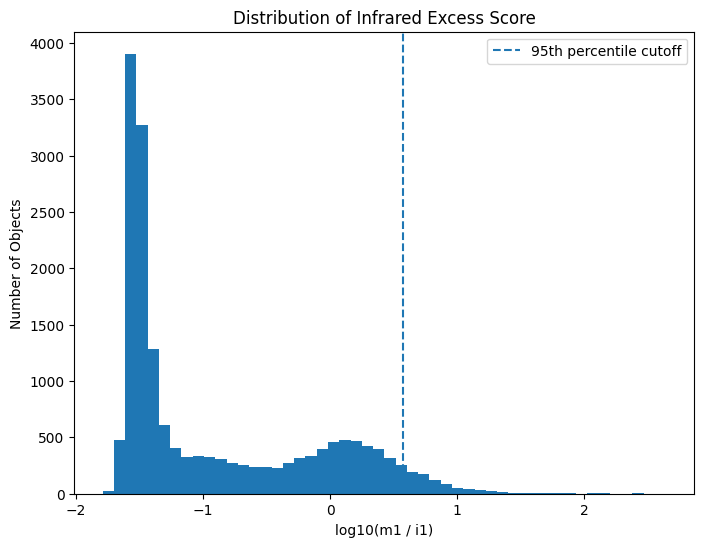

In [13]:
plt.figure(figsize=(8, 6))
plt.hist(df_ir["excess_score"], bins=50)
plt.axvline(cutoff, linestyle="--", label="95th percentile cutoff")
plt.title("Distribution of Infrared Excess Score")
plt.xlabel("log10(m1 / i1)")
plt.ylabel("Number of Objects")
plt.legend()
plt.show()

## 14. Ratio-Based Scatter Plot

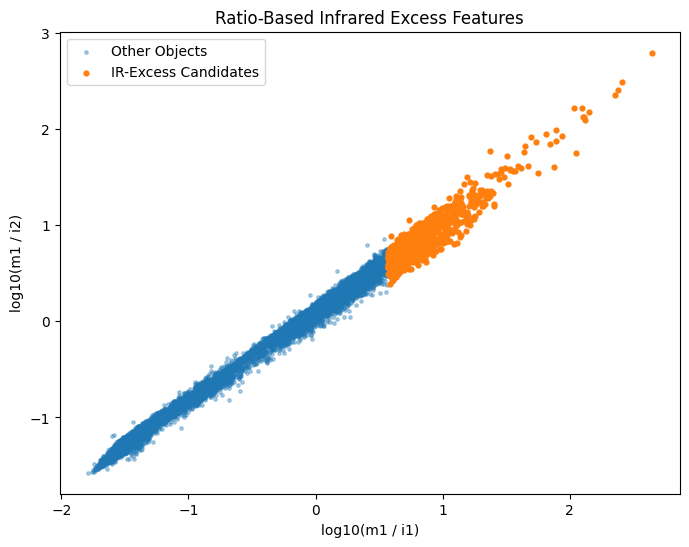

In [14]:
plt.figure(figsize=(8, 6))

normal = df_ir[~df_ir["ir_excess_candidate"]]
candidates = df_ir[df_ir["ir_excess_candidate"]]

plt.scatter(normal["log_m1_i1"], normal["log_m1_i2"], s=6, alpha=0.35, label="Other Objects")
plt.scatter(candidates["log_m1_i1"], candidates["log_m1_i2"], s=12, label="IR-Excess Candidates")

plt.title("Ratio-Based Infrared Excess Features")
plt.xlabel("log10(m1 / i1)")
plt.ylabel("log10(m1 / i2)")
plt.legend()
plt.show()

## 15. PCA Plot Colored by Cluster

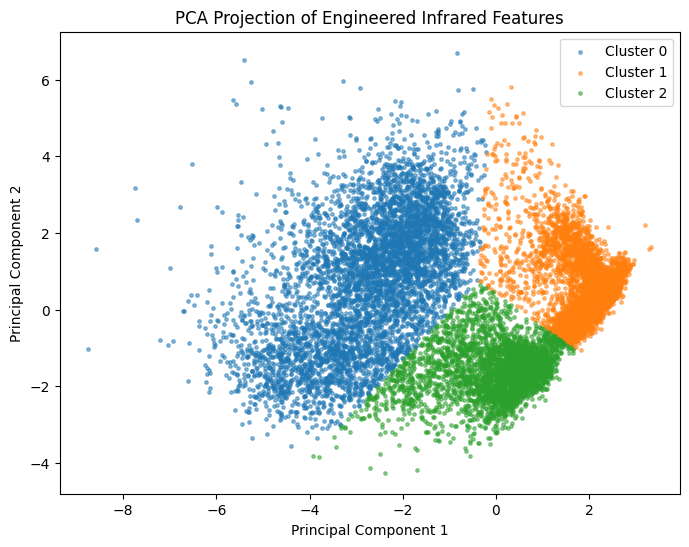

In [15]:
plt.figure(figsize=(8, 6))

for c in sorted(df_ir["cluster"].unique()):
    subset = df_ir[df_ir["cluster"] == c]
    plt.scatter(subset["pc1"], subset["pc2"], s=6, alpha=0.5, label=f"Cluster {c}")

plt.title("PCA Projection of Engineered Infrared Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

## 16. PCA Plot with Candidates Highlighted

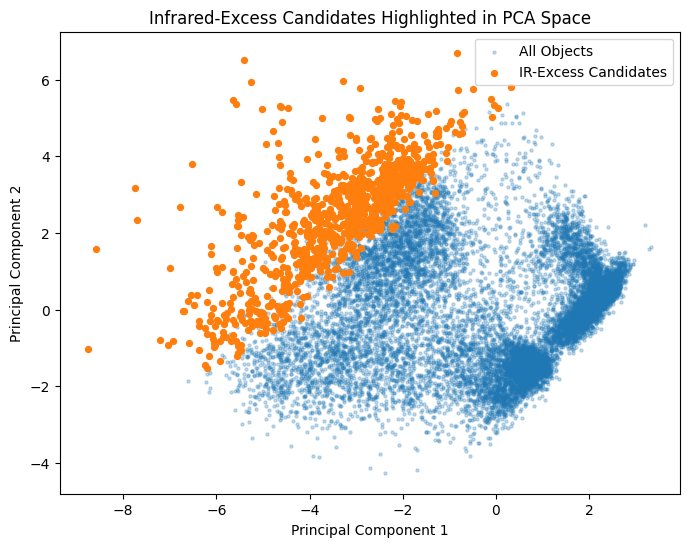

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(df_ir["pc1"], df_ir["pc2"], s=5, alpha=0.25, label="All Objects")
plt.scatter(
    df_ir.loc[df_ir["ir_excess_candidate"], "pc1"],
    df_ir.loc[df_ir["ir_excess_candidate"], "pc2"],
    s=18,
    label="IR-Excess Candidates"
)

plt.title("Infrared-Excess Candidates Highlighted in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

## 17. Save Candidate Results

This creates a CSV file with the top infrared-excess candidates so the project has an output file.

In [ ]:
top_candidates.to_csv("top_ir_excess_candidates.csv", index=False)

print("Saved top candidates to top_ir_excess_candidates.csv")

##Findings

This project found that a small group of objects in the SEIP infrared catalog had unusually strong 24-micron emission compared to their shorter-wavelength infrared flux measurements.

After cleaning the dataset and creating flux-ratio features, I used `log10(m1/i1)` as the main infrared-excess score. Objects in the top 5% of this score were flagged as possible infrared-excess candidates.

The histogram showed that these flagged objects were located at the high end of the excess-score distribution. The ratio-based scatter plot also showed that the candidates had noticeably higher 24-micron flux relative to the shorter infrared bands. PCA helped visualize the engineered features in two dimensions and revealed that some candidate objects appeared in a different region of feature space than the rest of the dataset.

These findings suggest that flux-ratio features can help identify objects with unusual infrared behavior. However, the flagged objects should be treated as candidate detections rather than confirmed classifications because this project did not compare them against known astronomical object labels.

## Reflection

I started this project to help me practice working with real data from start to finish. I started with raw SEIP infrared catalog data, cleaned the usable flux measurements, created ratio-based features, and used those features to identify objects with unusually strong 24-micron emission.

This project was less about building a perfect astronomy classifier and more about learning how to transform scientific data into meaningful features, analyze patterns, and visualize potential candidates. In the future, I would like to compare the flagged candidates with known object labels or use more astronomy-specific methods to better validate the results.

